# Executive Summary

This notebook explores the CBS labour market dataset (85920NED) covering quarterly employment indicators in the Netherlands from 1995 to 2025. The analysis examines trends across time, sectors, and worker types using three main indicators: WerkzamePersonen, Banen, and GewerkteUren. Results show strong long-term employment growth, structural differences between sectors, increasing labour market flexibility (more jobs per worker), and clear seasonal patterns in working hours. These labour market dynamics can be used to construct macro-economic, sectoral, and seasonal features that may help improve sick leave prediction models.

# Cleaning 85920NED Data

This notebook will load, clean, and visualize the 85920NED dataset from the project data folder.

## 1. Import required libraries

In [4]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Reading the table from Silver Database

In [5]:
from pathlib import Path
import sqlite3
import pandas as pd

# Path to the silver database
db_path = Path("../../data/2_silver/silver_data.db")

# Connect to the database
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path}")

# List available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print("Available tables:", tables["name"].tolist())

# Read the table (IMPORTANT: quote table name because it starts with a number)
table_name = "85920NED_silver"

df_85920NED = pd.read_sql_query(
    f'SELECT * FROM "{table_name}"',
    conn
)

print(f"Loaded {len(df_85920NED)} rows from {table_name}")
display(df_85920NED.head())

Connected to ..\..\data\2_silver\silver_data.db
Available tables: ['83157NED_silver', '80072ned_silver', '83415NED_silver', '85916NED_silver', '85918NED_silver', '85919NED_silver', '85920NED_silver', '85916NED_silver_SH', '85918NED_silver_SH', '85919NED_silver_SH']
Loaded 7440 rows from 85920NED_silver


,silver_id,bronze_pk,ID,TypeWerkenden,BedrijfstakkenBranchesSBI2008,Perioden,WerkzamePersonen_1,WerkzamePersonenSeizoengecorrigeerd_2,Banen_3,BanenSeizoengecorrigeerd_4,...,_source_file,BedrijfstakkenBranchesSBI2008_Title,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001413,T001081,1995KW01,7132.0,7215.0,7913.0,8000.0,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 1e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
1,2,TypedDataSet.json_1,1,T001413,T001081,1995KW02,7273.0,7249.0,8069.0,8043.0,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 2e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
2,3,TypedDataSet.json_2,2,T001413,T001081,1995KW03,7363.0,7297.0,8167.0,8097.0,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 3e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
3,4,TypedDataSet.json_3,3,T001413,T001081,1995KW04,7351.0,7358.0,8158.0,8167.0,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 4e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
4,5,TypedDataSet.json_4,4,T001413,T001081,1995JJ00,7281.0,None,8078.0,None,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None


## 3. Data Cleaning

### Standardize column data types for the full table

In [6]:
# --- Standardize column data types for the full table ---


# 1. Convert key / ID columns
df_85920NED["silver_id"] = df_85920NED["silver_id"].astype("int64")
df_85920NED["bronze_pk"] = df_85920NED["bronze_pk"].astype("string")
df_85920NED["ID"] = df_85920NED["ID"].astype("string")

# 2. Convert dimension code columns
dim_cols = [
    "TypeWerkenden",
    "BedrijfstakkenBranchesSBI2008",
    "Perioden"
]

df_85920NED[dim_cols] = df_85920NED[dim_cols].astype("string")

# 3. Convert descriptive text columns
text_cols = [
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_Description",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status",
    "TypeWerkenden_Title",
    "TypeWerkenden_Description",
    "_source_file"
]

df_85920NED[text_cols] = df_85920NED[text_cols].astype("string")

# 4. Convert numeric CBS variables
numeric_cols = [
    "WerkzamePersonen_1",
    "WerkzamePersonenSeizoengecorrigeerd_2",
    "Banen_3",
    "BanenSeizoengecorrigeerd_4",
    "GewerkteUren_5",
    "GewerkteUrenSeizoengecorrigeerd_6",
    "WerkzamePersonen_7",
    "Banen_8",
    "WerkzamePersonenSeizoengecorrigeerd_9",
    "BanenSeizoengecorrigeerd_10"
]

df_85920NED[numeric_cols] = df_85920NED[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# 5. Convert remaining object columns (empty category columns)
remaining_cols = [
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID"
]

df_85920NED[remaining_cols] = df_85920NED[remaining_cols].astype("string")

# 6. Final check
df_85920NED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7440 entries, 0 to 7439
Data columns (total 26 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      7440 non-null   int64  
 1   bronze_pk                                      7440 non-null   string 
 2   ID                                             7440 non-null   string 
 3   TypeWerkenden                                  7440 non-null   string 
 4   BedrijfstakkenBranchesSBI2008                  7440 non-null   string 
 5   Perioden                                       7440 non-null   string 
 6   WerkzamePersonen_1                             7130 non-null   float64
 7   WerkzamePersonenSeizoengecorrigeerd_2          5704 non-null   float64
 8   Banen_3                                        7130 non-null   float64
 9   BanenSeizoengecorrigeerd_4                     5704 

### Convert CBS Perioden codes into datetime + frequency

In [7]:
# --- Standard CBS Perioden → time dimension conversion ---



# 1. Determine frequency
df_85920NED["frequency"] = np.select(
    [
        df_85920NED["Perioden"].str.contains("KW"),
        df_85920NED["Perioden"].str.contains("MM"),
        df_85920NED["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)

# 2. Extract year
df_85920NED["year"] = df_85920NED["Perioden"].str[:4].astype(int)

# 3. Extract quarter
df_85920NED["quarter"] = df_85920NED["Perioden"].str.extract(r"KW(\d{2})")[0]
df_85920NED["quarter"] = pd.to_numeric(df_85920NED["quarter"], errors="coerce")

# 4. Create empty datetime column
df_85920NED["period_enddate"] = pd.NaT

# --- Quarterly periods ---
mask_q = df_85920NED["frequency"] == "quarterly"

df_85920NED.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex(
        year=df_85920NED.loc[mask_q, "year"],
        quarter=df_85920NED.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)

# --- Annual periods ---
mask_y = df_85920NED["frequency"] == "annual"

df_85920NED.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df_85920NED.loc[mask_y, "year"].astype(str) + "-12-31"
)

# --- Monthly periods (future-proof) ---
mask_m = df_85920NED["frequency"] == "monthly"

month = df_85920NED.loc[mask_m, "Perioden"].str.extract(r"MM(\d{2})")[0]
month = pd.to_numeric(month, errors="coerce")

df_85920NED.loc[mask_m, "period_enddate"] = (
    pd.to_datetime(dict(
        year=df_85920NED.loc[mask_m, "year"],
        month=month,
        day=1
    )) + pd.offsets.MonthEnd(0)
)

# 5. Clean timestamp precision
df_85920NED["period_enddate"] = pd.to_datetime(df_85920NED["period_enddate"]).dt.normalize()

# 6. Convert quarter to nullable integer
df_85920NED["quarter"] = df_85920NED["quarter"].astype("Int64")

# 7. Check result
df_85920NED[["Perioden", "frequency", "year", "quarter", "period_enddate"]].head(10)

C:\Users\Yanni\AppData\Local\Temp\ipykernel_19096\3091779298.py:34: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  pd.PeriodIndex(


,Perioden,frequency,year,quarter,period_enddate
0,1995KW01,quarterly,1995,1,1995-03-31
1,1995KW02,quarterly,1995,2,1995-06-30
2,1995KW03,quarterly,1995,3,1995-09-30
3,1995KW04,quarterly,1995,4,1995-12-31
4,1995JJ00,annual,1995,<NA>,1995-12-31
5,1996KW01,quarterly,1996,1,1996-03-31
6,1996KW02,quarterly,1996,2,1996-06-30
7,1996KW03,quarterly,1996,3,1996-09-30
8,1996KW04,quarterly,1996,4,1996-12-31
9,1996JJ00,annual,1996,<NA>,1996-12-31


### DataFrame structural cleaning

In [8]:
# --- DataFrame structural cleaning ---

# 1. Rename columns
df_85920NED = df_85920NED.rename(columns={
    "BedrijfstakkenBranchesSBI2008": "sbi_code",

    "WerkzamePersonen_1": "WerkzamePersonen",
    "WerkzamePersonenSeizoengecorrigeerd_2": "WerkzamePersonenSeizoengecorrigeerd",
    "Banen_3": "Banen",
    "BanenSeizoengecorrigeerd_4": "BanenSeizoengecorrigeerd",
    "GewerkteUren_5": "GewerkteUren",
    "GewerkteUrenSeizoengecorrigeerd_6": "GewerkteUrenSeizoengecorrigeerd"
})


# 2. Drop columns that represent changes vs previous period
cols_to_drop = [
    "WerkzamePersonen_7",
    "Banen_8",
    "WerkzamePersonenSeizoengecorrigeerd_9",
    "BanenSeizoengecorrigeerd_10"
]

df_85920NED = df_85920NED.drop(columns=cols_to_drop)


# 3. Reorder columns (bring time fields after Perioden)

cols = list(df_85920NED.columns)

cols.remove("frequency")
cols.remove("year")
cols.remove("quarter")
cols.remove("period_enddate")

period_index = cols.index("Perioden")

new_cols = (
    cols[:period_index + 1] +
    ["frequency", "year", "quarter", "period_enddate"] +
    cols[period_index + 1:]
)

df_85920NED = df_85920NED[new_cols]


# 4. Verify result
df_85920NED.columns
df_85920NED.head()

,silver_id,bronze_pk,ID,TypeWerkenden,sbi_code,Perioden,frequency,year,quarter,period_enddate,...,_source_file,BedrijfstakkenBranchesSBI2008_Title,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001413,T001081,1995KW01,quarterly,1995,1,1995-03-31,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 1e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
1,2,TypedDataSet.json_1,1,T001413,T001081,1995KW02,quarterly,1995,2,1995-06-30,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 2e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
2,3,TypedDataSet.json_2,2,T001413,T001081,1995KW03,quarterly,1995,3,1995-09-30,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 3e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
3,4,TypedDataSet.json_3,3,T001413,T001081,1995KW04,quarterly,1995,4,1995-12-31,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 4e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
4,5,TypedDataSet.json_4,4,T001413,T001081,1995JJ00,annual,1995,<NA>,1995-12-31,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,<NA>,1995,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>


## 4. Uploading the new data table to Silver Database

In [9]:
df_85920NED.to_sql(
    "85920NED_silver_SH",
    conn,
    if_exists="replace",
    index=False
)

df_check = pd.read_sql_query(
    'SELECT * FROM "85920NED_silver_SH"',
    conn
)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

df_check.head()

df_check.dtypes
df_check.isna().sum()

Rows: 7440
Columns: 26


silver_id                                           0
bronze_pk                                           0
ID                                                  0
TypeWerkenden                                       0
sbi_code                                            0
Perioden                                            0
frequency                                           0
year                                                0
quarter                                          1488
period_enddate                                      0
WerkzamePersonen                                  310
WerkzamePersonenSeizoengecorrigeerd              1736
Banen                                             310
BanenSeizoengecorrigeerd                         1736
GewerkteUren                                      310
GewerkteUrenSeizoengecorrigeerd                  1736
_source_file                                        0
BedrijfstakkenBranchesSBI2008_Title                 0
BedrijfstakkenBranchesSBI200

# Data Exploration

### raeding the clean table for EDA

In [10]:
# Load cleaned table from the Silver database
df_85920NED_clean = pd.read_sql_query(
    'SELECT * FROM "85920NED_silver_SH"',
    conn
)

# Quick validation
print("Rows:", df_85920NED_clean.shape[0])
print("Columns:", df_85920NED_clean.shape[1])

df_85920NED_clean.head()

Rows: 7440
Columns: 26


,silver_id,bronze_pk,ID,TypeWerkenden,sbi_code,Perioden,frequency,year,quarter,period_enddate,...,_source_file,BedrijfstakkenBranchesSBI2008_Title,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001413,T001081,1995KW01,quarterly,1995,1.0,1995-03-31 00:00:00,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 1e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
1,2,TypedDataSet.json_1,1,T001413,T001081,1995KW02,quarterly,1995,2.0,1995-06-30 00:00:00,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 2e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
2,3,TypedDataSet.json_2,2,T001413,T001081,1995KW03,quarterly,1995,3.0,1995-09-30 00:00:00,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 3e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
3,4,TypedDataSet.json_3,3,T001413,T001081,1995KW04,quarterly,1995,4.0,1995-12-31 00:00:00,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 4e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
4,5,TypedDataSet.json_4,4,T001413,T001081,1995JJ00,annual,1995,NaN,1995-12-31 00:00:00,...,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None


In [11]:
# -----------------------------
# Fix datatypes for analysis
# -----------------------------

import pandas as pd

# 1. Date column
df_85920NED_clean["period_enddate"] = pd.to_datetime(df_85920NED_clean["period_enddate"])

# 2. Integer columns
df_85920NED_clean["silver_id"] = df_85920NED_clean["silver_id"].astype("int64")
df_85920NED_clean["year"] = df_85920NED_clean["year"].astype("int64")

# quarter contains missing values -> nullable integer
df_85920NED_clean["quarter"] = df_85920NED_clean["quarter"].astype("Int64")

# 3. Numeric variables (labour indicators)
numeric_cols = [
    "WerkzamePersonen",
    "WerkzamePersonenSeizoengecorrigeerd",
    "Banen",
    "BanenSeizoengecorrigeerd",
    "GewerkteUren",
    "GewerkteUrenSeizoengecorrigeerd"
]

df_85920NED_clean[numeric_cols] = df_85920NED_clean[numeric_cols].astype("float64")

# 4. Categorical variables (few repeated values)
category_cols = [
    "TypeWerkenden",
    "sbi_code",
    "frequency",
    "BedrijfstakkenBranchesSBI2008_Title",
    "Perioden_Status",
    "TypeWerkenden_Title"
]

df_85920NED_clean[category_cols] = df_85920NED_clean[category_cols].astype("category")

# 5. String / identifier fields
string_cols = [
    "bronze_pk",
    "ID",
    "Perioden",
    "_source_file",
    "BedrijfstakkenBranchesSBI2008_Description",
    "Perioden_Title",
    "Perioden_Description",
    "TypeWerkenden_Description",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID"
]

df_85920NED_clean[string_cols] = df_85920NED_clean[string_cols].astype("string")

# 6. Verify
df_85920NED_clean.dtypes

silver_id                                                 int64
bronze_pk                                        string[python]
ID                                               string[python]
TypeWerkenden                                          category
sbi_code                                               category
Perioden                                         string[python]
frequency                                              category
year                                                      int64
quarter                                                   Int64
period_enddate                                   datetime64[ns]
WerkzamePersonen                                        float64
WerkzamePersonenSeizoengecorrigeerd                     float64
Banen                                                   float64
BanenSeizoengecorrigeerd                                float64
GewerkteUren                                            float64
GewerkteUrenSeizoengecorrigeerd         

### Dataset Overview

Rows: 7440
Columns: 26

Time coverage:
Start: 1995-03-31 00:00:00
End: 2025-12-31 00:00:00

Frequency distribution:
frequency
quarterly    5952
annual       1488
Name: count, dtype: int64

Worker type distribution:
TypeWerkenden_Title
Totaal           2480
Werknemers       2480
Zelfstandigen    2480
Name: count, dtype: int64

Number of sectors:
16

Example sector names:
['A-U Alle economische activiteiten', 'A Landbouw, bosbouw en visserij', 'B-E Nijverheid (geen bouw) en energie', 'C Industrie', 'F Bouwnijverheid', 'G-I Handel, vervoer en horeca', 'J Informatie en communicatie', 'K Financiële dienstverlening', 'L Verhuur en handel van onroerend goed', 'M-N Zakelijke dienstverlening']
Categories (16, object): ['78 Uitzendbureaus en arbeidsbemiddeling', 'A Landbouw, bosbouw en visserij', 'A-U Alle economische activiteiten', 'B-E Nijverheid (geen bouw) en energie', ..., 'O-Q Overheid en zorg', 'P Onderwijs', 'Q Gezondheids- en welzijnszorg', 'R-U Cultuur, recreatie, overige diensten']

M

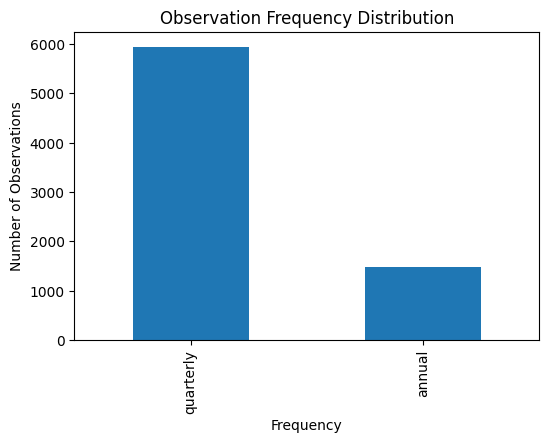

In [12]:
# 1. Dataset size
print("Rows:", df_85920NED_clean.shape[0])
print("Columns:", df_85920NED_clean.shape[1])

# 2. Time coverage
print("\nTime coverage:")
print("Start:", df_85920NED_clean["period_enddate"].min())
print("End:", df_85920NED_clean["period_enddate"].max())

# 3. Frequency distribution
print("\nFrequency distribution:")
print(df_85920NED_clean["frequency"].value_counts())

# 4. Worker type distribution
print("\nWorker type distribution:")
print(df_85920NED_clean["TypeWerkenden_Title"].value_counts())

# 5. Sector coverage
print("\nNumber of sectors:")
print(df_85920NED_clean["sbi_code"].nunique())

print("\nExample sector names:")
print(df_85920NED_clean["BedrijfstakkenBranchesSBI2008_Title"].unique()[:10])

# 6. Missing values overview
print("\nMissing values per column:")
print(df_85920NED_clean.isna().sum().sort_values(ascending=False))

# 7. Quick visualization of frequency distribution
plt.figure(figsize=(6,4))
df_85920NED_clean["frequency"].value_counts().plot(kind="bar")
plt.title("Observation Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Observations")
plt.show()

#### Interpretation (Dataset Overview)

Dataset size and coverage

The dataset contains 7,440 observations and 26 variables, covering the period 1995–2025.
This provides roughly 30 years of labour market history, which is sufficient for identifying long-term labour trends and structural changes.

Frequency distribution

Most observations are quarterly (5,952), while 1,488 observations are annual aggregates.
Quarterly data provides the most useful time resolution for modelling labour market dynamics and potentially linking them to seasonal sickness patterns.

Worker type distribution

The dataset includes three worker categories:

Totaal (Total workforce)

Werknemers (Employees)

Zelfstandigen (Self-employed)

Each category contains the same number of observations (2,480), indicating a balanced dataset across worker types.

This distinction may be relevant for sick leave modelling, as employees and self-employed workers face different insurance structures and sickness reporting behaviors.

Sector coverage

The dataset covers 16 economic sectors, based on the SBI 2008 classification.
Examples include:

Agriculture

Manufacturing

Construction

Trade, transport and hospitality

Financial services

Business services

Sector differences may play an important role in explaining variation in sick leave rates, since working conditions and job characteristics vary widely across industries.

Missing values

Several patterns appear in the missing data:

Seasonally adjusted variables contain missing values because they are only available for quarterly observations.

The quarter variable is missing for annual observations, which is expected.

Some labour indicators (persons employed, jobs, hours worked) contain small numbers of missing values, which may reflect data availability issues in early periods or sector definitions.

Two metadata columns (CategoryGroupID) are entirely empty and likely originate from the CBS dimension tables; they are not relevant for analysis.

### National Labour Trends

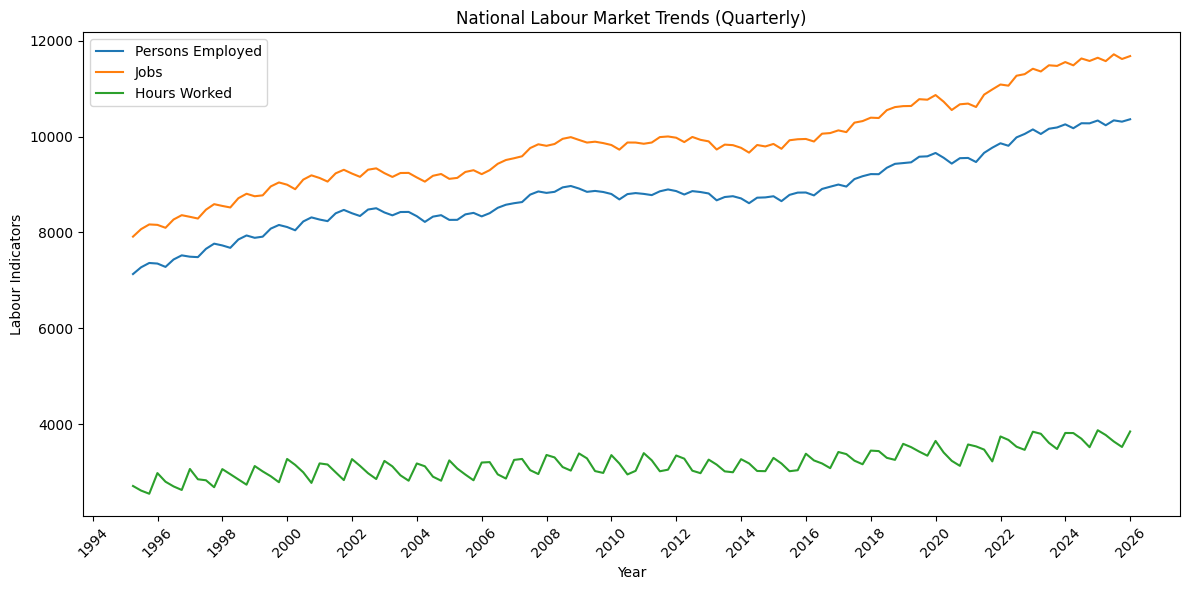

In [13]:
# -----------------------------
# M1.5.2 National Labour Trends
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use quarterly observations
df_q = df_85920NED_clean[df_85920NED_clean["frequency"] == "quarterly"]

# Use total workforce
df_total = df_q[df_q["TypeWerkenden_Title"] == "Totaal"]

# Use national total sector
df_national = df_total[df_total["sbi_code"] == "T001081"]

# Sort by time
df_national = df_national.sort_values("period_enddate")

# Plot labour indicators
plt.figure(figsize=(12,6))

plt.plot(df_national["period_enddate"], df_national["WerkzamePersonen"], label="Persons Employed")
plt.plot(df_national["period_enddate"], df_national["Banen"], label="Jobs")
plt.plot(df_national["period_enddate"], df_national["GewerkteUren"], label="Hours Worked")

plt.title("National Labour Market Trends (Quarterly)")
plt.xlabel("Year")
plt.ylabel("Labour Indicators")
plt.legend()

# Improve x-axis readability
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation – National Labour Market Trends

Long-term labour market expansion

All three indicators — persons employed, number of jobs, and hours worked — show a clear upward trend from the mid-1990s to 2025. This indicates strong long-term growth in the Dutch labour market.

The number of employed persons increases from roughly 7.2 million in the mid-1990s to over 10 million in recent years, reflecting population growth, increased labour participation, and economic expansion.

For the UWV case, sustained labour market growth may imply increasing pressure on the workforce, which could influence absenteeism rates.

Jobs exceed number of employed persons

The number of jobs is consistently higher than the number of employed persons throughout the entire period. This indicates that a portion of the workforce holds multiple jobs simultaneously.

This phenomenon may affect absenteeism dynamics, as individuals with multiple jobs may experience higher workload or fatigue, potentially increasing the risk of sick leave.

Strong seasonal pattern in hours worked

The hours worked series shows clear quarterly seasonality, with recurring peaks and dips every year. This reflects typical labour market patterns such as holiday periods and seasonal industry activity.

Seasonality is particularly relevant for the UWV project, as sick leave rates also exhibit seasonal patterns, especially during winter months.

Impact of economic shocks

The labour market trends show visible slowdowns or temporary declines during major economic disruptions:

2008–2009 financial crisis: a short stagnation period in employment and jobs.

2020 COVID-19 pandemic: a noticeable dip in labour indicators.

These periods may correspond to changes in absenteeism patterns, as economic uncertainty and health crises can influence both labour demand and employee health.

Strong growth after 2014

After approximately 2014, the labour market shows accelerated growth across all indicators. This period corresponds to a tightening labour market in the Netherlands.

A tight labour market can increase work pressure and overtime, which may influence burnout and sickness absence rates.


The difference between jobs and employed persons appears to widen slightly over time, suggesting increasing labour market flexibility and multiple job holding. This is actually a very interesting labour market signal.

### Sector level trends

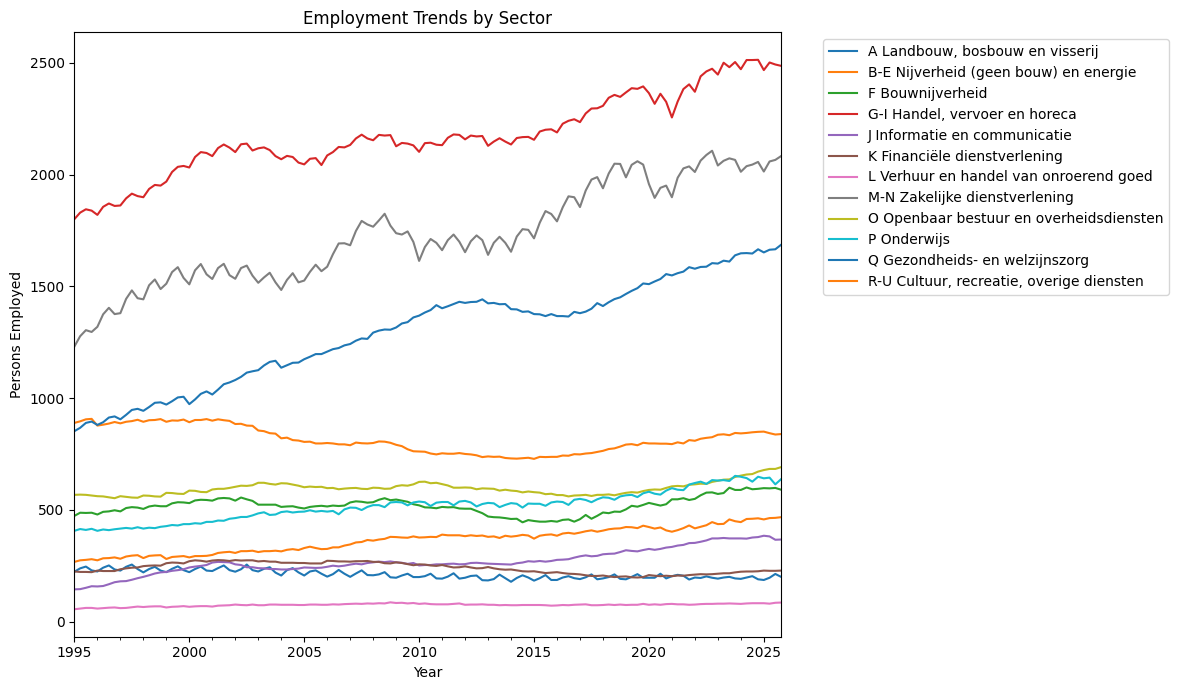

In [14]:
# -----------------------------
# M1.5.3 Sector trends
# -----------------------------

import matplotlib.pyplot as plt

# Use quarterly observations
df_q = df_85920NED_clean[df_85920NED_clean["frequency"] == "quarterly"]

# Use total workforce
df_total = df_q[df_q["TypeWerkenden_Title"] == "Totaal"]

# Keep only consistent sector set
selected_sectors = [
    "301000",
    "300002",
    "350000",
    "300006",
    "391600",
    "396300",
    "402000",
    "300010",
    "417400",
    "419000",
    "422400",
    "300014"
]

df_sector = df_total[df_total["sbi_code"].isin(selected_sectors)]

# Create sector time series
sector_trends = (
    df_sector
    .pivot_table(
        index="period_enddate",
        columns="BedrijfstakkenBranchesSBI2008_Title",
        values="WerkzamePersonen",
        observed=True
    )
)

# Plot
sector_trends.plot(figsize=(12,7))

plt.title("Employment Trends by Sector")
plt.xlabel("Year")
plt.ylabel("Persons Employed")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

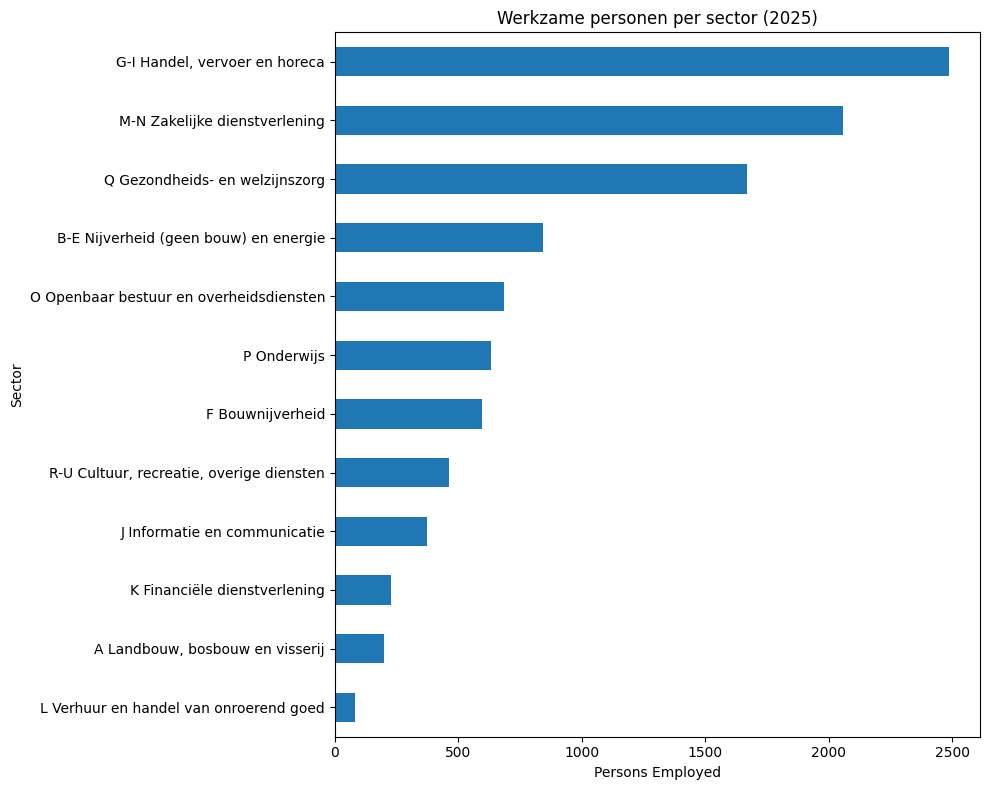

In [15]:
# -----------------------------
# 5.3.2 Sector size comparison
# -----------------------------

# Identify the latest year in the dataset
latest_year = df_sector["year"].max()

# Aggregate employment by sector for that year
sector_latest = (
    df_sector[df_sector["year"] == latest_year]
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=True)["WerkzamePersonen"]
    .mean()
    .sort_values()
)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))

sector_latest.plot(kind="barh")

plt.title(f"Werkzame personen per sector ({latest_year})")
plt.xlabel("Persons Employed")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [16]:
# -----------------------------
# 5.3.3 Sector growth over time
# -----------------------------

# Compute sector growth between first and last observation
sector_growth = (
    df_sector
    .sort_values("period_enddate")
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=True)["WerkzamePersonen"]
    .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
    .sort_values(ascending=False)
)

sector_growth

BedrijfstakkenBranchesSBI2008_Title
J Informatie en communicatie                154.861111
Q Gezondheids- en welzijnszorg               97.887324
R-U Cultuur, recreatie, overige diensten     74.906367
M-N Zakelijke dienstverlening                69.212023
P Onderwijs                                  56.896552
L Verhuur en handel van onroerend goed       54.545455
G-I Handel, vervoer en horeca                38.089950
F Bouwnijverheid                             24.735729
O Openbaar bestuur en overheidsdiensten      21.869489
K Financiële dienstverlening                  1.785714
B-E Nijverheid (geen bouw) en energie        -5.624297
A Landbouw, bosbouw en visserij             -10.313901
Name: WerkzamePersonen, dtype: float64

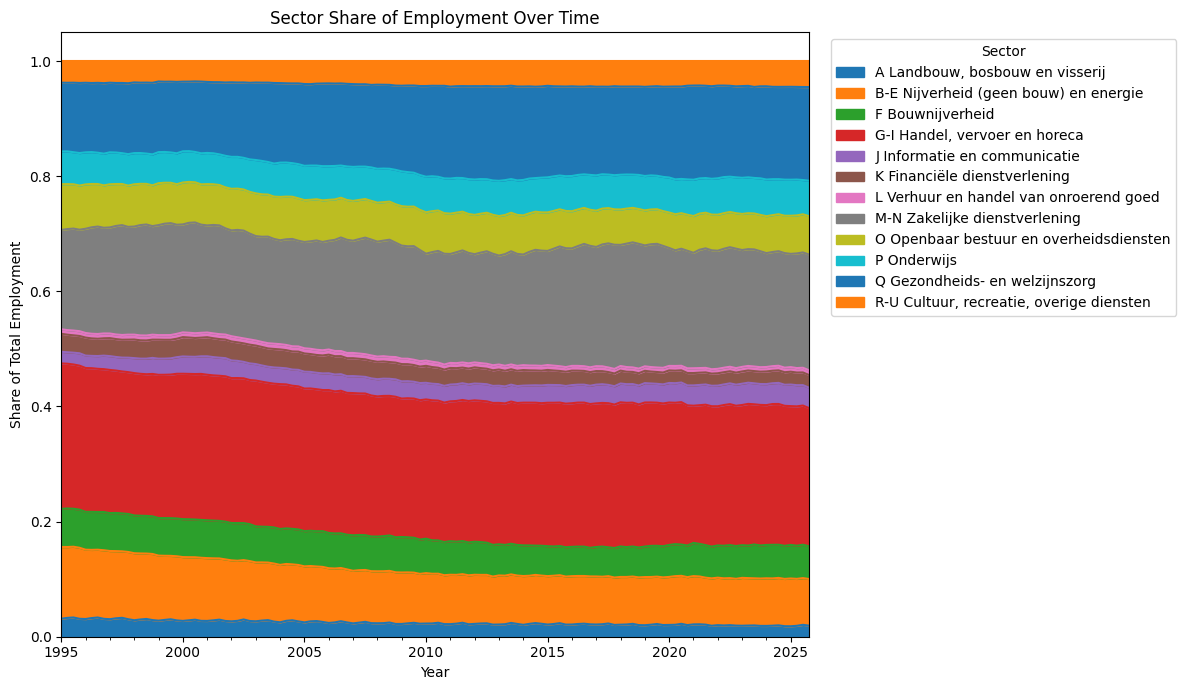

In [17]:
# -----------------------------
# 5.3.4 Sector share of employment
# -----------------------------

sector_share = (
    df_sector
    .pivot_table(
        index="period_enddate",
        columns="BedrijfstakkenBranchesSBI2008_Title",
        values="WerkzamePersonen",
        observed=True
    )
)

# Convert to shares
sector_share = sector_share.div(sector_share.sum(axis=1), axis=0)

# Plot
ax = sector_share.plot.area(figsize=(12,7))

plt.title("Sector Share of Employment Over Time")
plt.ylabel("Share of Total Employment")
plt.xlabel("Year")

# Move legend outside the chart
plt.legend(
    title="Sector",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

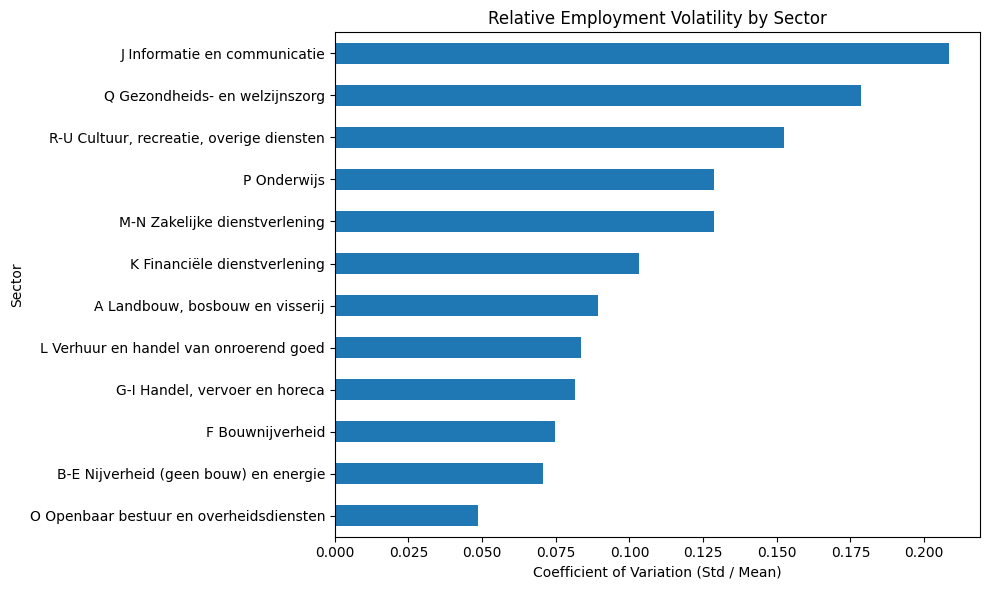

In [18]:
# -----------------------------
# Relative sector volatility
# -----------------------------

sector_rel_volatility = (
    df_sector
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=True)["WerkzamePersonen"]
    .apply(lambda x: x.std() / x.mean())
    .sort_values(ascending=False)
)

sector_rel_volatility

plt.figure(figsize=(10,6))

sector_rel_volatility.sort_values().plot(kind="barh")

plt.title("Relative Employment Volatility by Sector")
plt.xlabel("Coefficient of Variation (Std / Mean)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [19]:
# -----------------------------
# Sector summary table
# -----------------------------

# Sector share (latest year)
sector_share_latest = sector_latest / sector_latest.sum() * 100

sector_summary = pd.DataFrame({
    "Employment (latest year)": sector_latest,
    "Share of employment (%)": sector_share_latest,
    "Employment growth (%)": sector_growth,
    "Relative volatility (%)": sector_rel_volatility * 100
})

# Sort by sector size
sector_summary = sector_summary.sort_values("Employment (latest year)", ascending=False)

sector_summary.round(2)

,Employment (latest year),Share of employment (%),Employment growth (%),Relative volatility (%)
BedrijfstakkenBranchesSBI2008_Title,,,,
"G-I Handel, vervoer en horeca",2487.50,24.12,38.09,8.14
M-N Zakelijke dienstverlening,2055.50,19.93,69.21,12.86
Q Gezondheids- en welzijnszorg,1667.00,16.17,97.89,17.86
B-E Nijverheid (geen bouw) en energie,842.25,8.17,-5.62,7.08
O Openbaar bestuur en overheidsdiensten,683.75,6.63,21.87,4.88
P Onderwijs,634.00,6.15,56.90,12.87
F Bouwnijverheid,595.25,5.77,24.74,7.48
"R-U Cultuur, recreatie, overige diensten",462.75,4.49,74.91,15.23
J Informatie en communicatie,374.50,3.63,154.86,20.85


#### Interpreation - Sector level trends

1. Employment trends by sector

The time-series analysis shows substantial differences in employment dynamics across sectors between 1995 and 2025.

The largest sector throughout the period is G-I Handel, vervoer en horeca, which consistently employs the highest number of workers. Employment in this sector increased from approximately 1.8 million to nearly 2.5 million workers, reflecting the importance of trade, transport, and hospitality activities in the Dutch economy.

Another major sector is M-N Zakelijke dienstverlening, which experienced strong growth over the period. Employment in this sector increased from roughly 1.3 million to over 2 million workers, highlighting the increasing importance of business services in the labour market.

The sector Q Gezondheids- en welzijnszorg also shows sustained growth, reflecting structural demographic changes and rising demand for healthcare services.

By contrast, B-E Nijverheid (geen bouw) en energie shows relatively stable or slightly declining employment levels, illustrating the long-term structural shift away from traditional industrial activities.

2. Sector size comparison (latest year)

The sector size comparison confirms that employment in the Netherlands is heavily concentrated in service sectors.

The three largest sectors in the most recent year are:

G-I Handel, vervoer en horeca (~24% of employment)

M-N Zakelijke dienstverlening (~20%)

Q Gezondheids- en welzijnszorg (~16%)

Together, these sectors account for over 60% of total employment in the analysed dataset.

Public sector activities also represent a significant share of employment. For example:

O Openbaar bestuur en overheidsdiensten

P Onderwijs

both employ large numbers of workers compared with smaller sectors such as A Landbouw, bosbouw en visserij or L Verhuur en handel van onroerend goed.

3. Sector share of employment over time

The sector share analysis reveals a structural transformation of the Dutch labour market.

The share of employment in B-E Nijverheid (geen bouw) en energie has gradually declined over the last decades. At the same time, service-oriented sectors such as:

M-N Zakelijke dienstverlening

Q Gezondheids- en welzijnszorg

J Informatie en communicatie

have increased their relative importance.

This pattern reflects the broader transition from a manufacturing-based economy toward a service-oriented economy.

4. Sector employment growth

Growth rates further illustrate these structural changes.

The fastest-growing sectors include:

J Informatie en communicatie (+155%)

Q Gezondheids- en welzijnszorg (+98%)

R-U Cultuur, recreatie, overige diensten (+75%)

M-N Zakelijke dienstverlening (+69%)

These sectors are primarily knowledge-intensive or service-oriented activities, which have expanded significantly over the last three decades.

In contrast, employment declined slightly in:

B-E Nijverheid (geen bouw) en energie

A Landbouw, bosbouw en visserij

reflecting long-term productivity improvements and structural shifts away from primary and industrial sectors.

5. Sector volatility

The analysis of relative employment volatility shows that fluctuations differ substantially across sectors.

The most volatile sectors include:

J Informatie en communicatie

Q Gezondheids- en welzijnszorg

R-U Cultuur, recreatie, overige diensten

These sectors show larger relative fluctuations in employment levels over time.

By contrast, employment is relatively stable in sectors such as:

O Openbaar bestuur en overheidsdiensten

B-E Nijverheid (geen bouw) en energie

F Bouwnijverheid

indicating more stable employment dynamics.

6. Key insights for the sick leave analysis

Several insights from the sector analysis may be relevant for the subsequent modelling of sick leave:

First, the Dutch labour market is dominated by service-oriented sectors, particularly Handel, vervoer en horeca, Zakelijke dienstverlening, and Gezondheids- en welzijnszorg.

Second, sectors experiencing strong employment growth, such as Informatie en communicatie and Gezondheids- en welzijnszorg, may exhibit different labour conditions and work patterns that could influence absenteeism.

Third, sectors with higher employment volatility may experience stronger labour market pressures, which could also affect sickness absence patterns.

These observations suggest that sector composition should be considered as a potential explanatory factor when analysing sick leave trends.

✅ Overall conclusion of Section 5.3

The Dutch labour market has become increasingly service-oriented, with strong employment growth in business services, healthcare, and information-related sectors, while traditional industrial sectors have declined in relative importance. These structural changes may influence labour market dynamics and should be considered when analysing patterns of sickness absence.

### Worker Type Analysis (Werknemers vs Zelfstandigen)

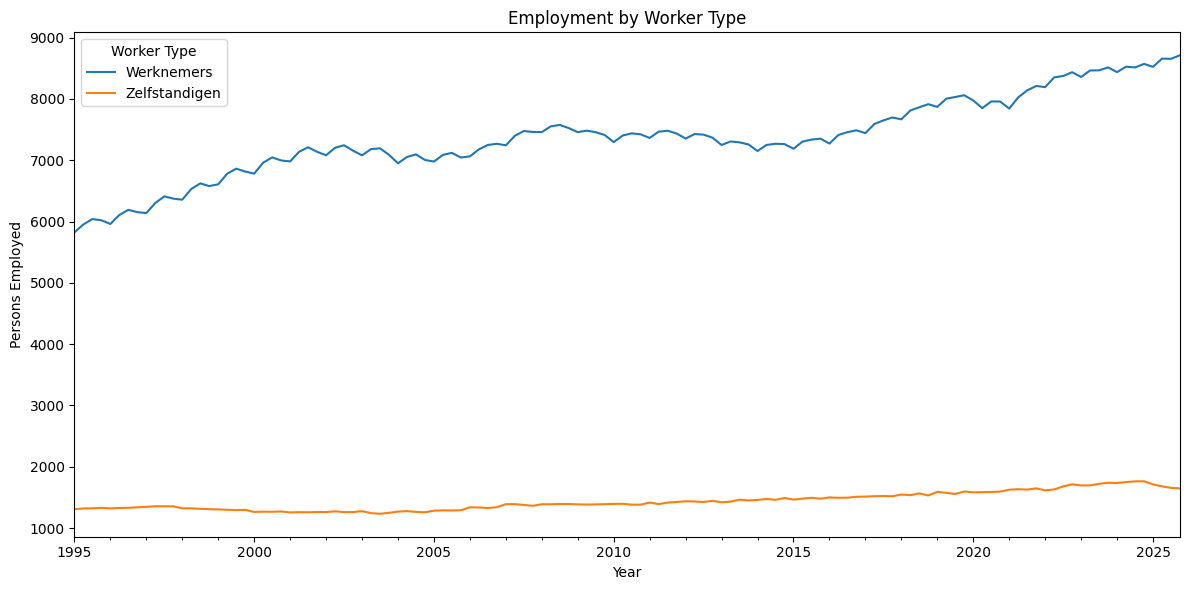

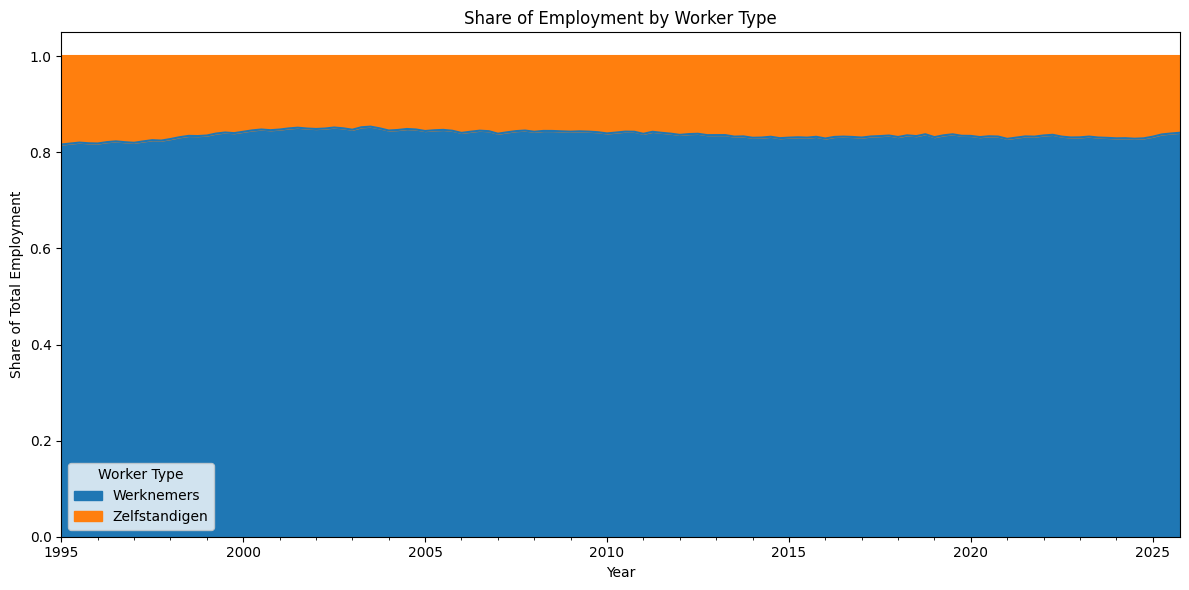

In [20]:
# -----------------------------
# 5.4.1 Worker type trends
# -----------------------------

df_worker = df_q[
    (df_q["sbi_code"] == "T001081") &
    (df_q["TypeWerkenden_Title"] != "Totaal")
]

worker_trends = (
    df_worker
    .pivot_table(
        index="period_enddate",
        columns="TypeWerkenden_Title",
        values="WerkzamePersonen",
        observed=True
    )
)

worker_trends.plot(figsize=(12,6))

plt.title("Employment by Worker Type")
plt.xlabel("Year")
plt.ylabel("Persons Employed")

plt.legend(title="Worker Type")

plt.tight_layout()
plt.show()

worker_share = worker_trends.div(worker_trends.sum(axis=1), axis=0)

worker_share.plot.area(figsize=(12,6))

plt.title("Share of Employment by Worker Type")
plt.xlabel("Year")
plt.ylabel("Share of Total Employment")

plt.legend(title="Worker Type")

plt.tight_layout()
plt.show()





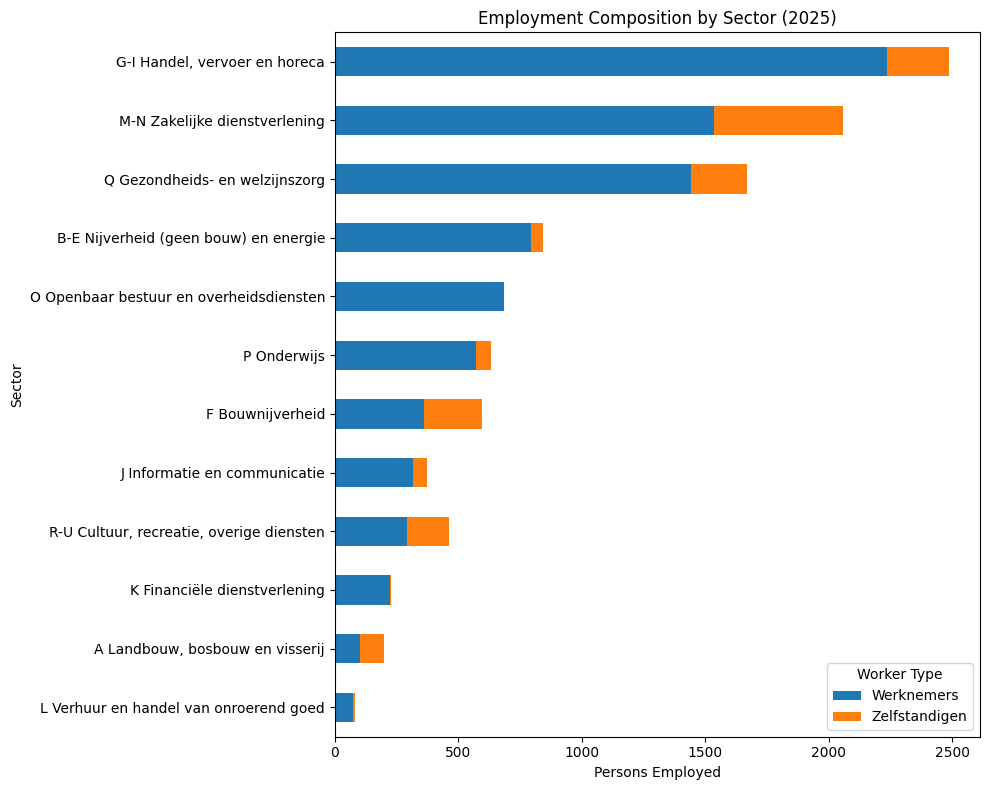

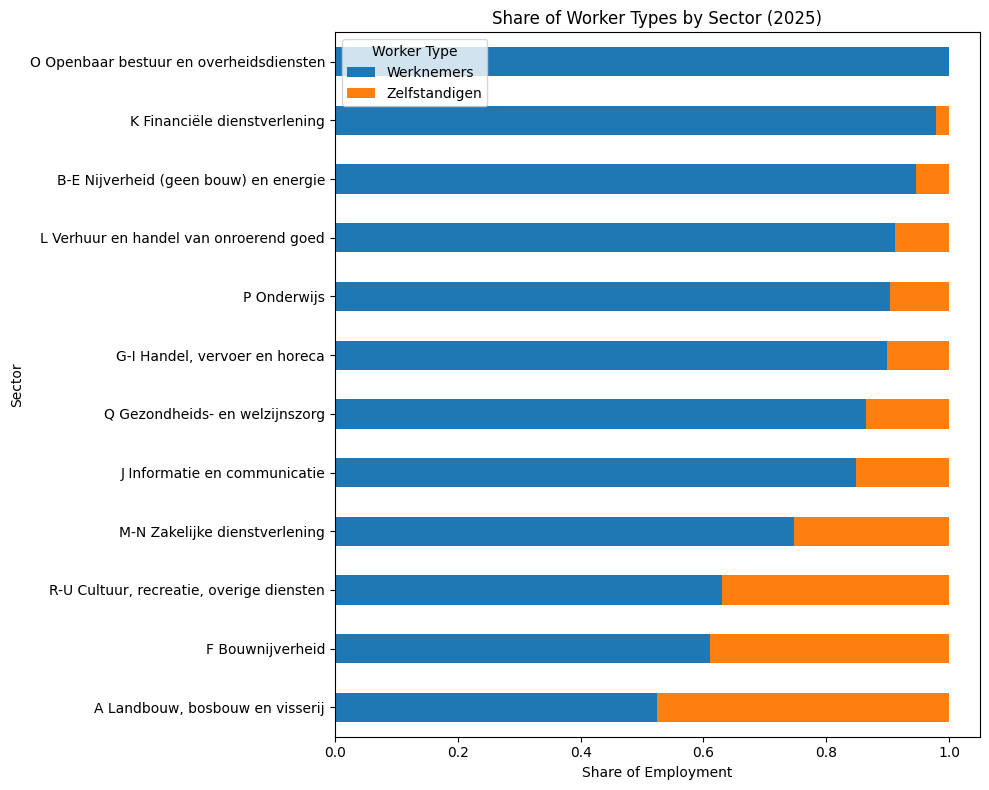

In [21]:
# -----------------------------
# 5.4.3 Worker type distribution by sector (latest year)
# -----------------------------

import matplotlib.pyplot as plt

# Filter sectors and exclude total
df_worker_sector = df_q[
    (df_q["sbi_code"].isin(selected_sectors)) &
    (df_q["TypeWerkenden_Title"] != "Totaal")
]

# Identify first and latest year
first_year = df_worker_sector["year"].min()
latest_year = df_worker_sector["year"].max()

# Pivot table for latest year
worker_sector_latest = (
    df_worker_sector[df_worker_sector["year"] == latest_year]
    .pivot_table(
        index="BedrijfstakkenBranchesSBI2008_Title",
        columns="TypeWerkenden_Title",
        values="WerkzamePersonen",
        aggfunc="mean",
        observed=True
    )
)

# -----------------------------
# Plot absolute employment
# -----------------------------

worker_sector_latest.sort_values("Werknemers").plot(
    kind="barh",
    stacked=True,
    figsize=(10,8)
)

plt.title(f"Employment Composition by Sector ({latest_year})")
plt.xlabel("Persons Employed")
plt.ylabel("Sector")

plt.legend(title="Worker Type")

plt.tight_layout()
plt.show()


# -----------------------------
# Plot worker type shares
# -----------------------------

worker_sector_share_latest = worker_sector_latest.div(
    worker_sector_latest.sum(axis=1),
    axis=0
)

worker_sector_share_latest.sort_values("Werknemers").plot(
    kind="barh",
    stacked=True,
    figsize=(10,8)
)

plt.title(f"Share of Worker Types by Sector ({latest_year})")
plt.xlabel("Share of Employment")
plt.ylabel("Sector")

plt.legend(title="Worker Type")

plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# Change in worker type share
# -----------------------------

# First year composition
worker_sector_first = (
    df_worker_sector[df_worker_sector["year"] == first_year]
    .pivot_table(
        index="BedrijfstakkenBranchesSBI2008_Title",
        columns="TypeWerkenden_Title",
        values="WerkzamePersonen",
        aggfunc="mean",
        observed=True
    )
)

# Convert to shares
share_first = worker_sector_first.div(worker_sector_first.sum(axis=1), axis=0)
share_latest = worker_sector_share_latest

# Create summary table
worker_change = pd.DataFrame({
    "Zelfstandigen share (" + str(first_year) + ")": share_first["Zelfstandigen"] * 100,
    "Zelfstandigen share (" + str(latest_year) + ")": share_latest["Zelfstandigen"] * 100
})

worker_change["Change in zelfstandigen share (pp)"] = (
    worker_change.iloc[:,1] - worker_change.iloc[:,0]
)

worker_change = worker_change.sort_values(
    "Change in zelfstandigen share (pp)",
    ascending=False
)

worker_change.round(2)

,Zelfstandigen share (1995),Zelfstandigen share (2025),Change in zelfstandigen share (pp)
BedrijfstakkenBranchesSBI2008_Title,,,
F Bouwnijverheid,23.86,39.02,15.16
P Onderwijs,6.56,9.70,3.14
"R-U Cultuur, recreatie, overige diensten",35.49,36.99,1.49
J Informatie en communicatie,14.88,15.22,0.34
O Openbaar bestuur en overheidsdiensten,0.00,0.00,0.00
Q Gezondheids- en welzijnszorg,14.79,13.62,-1.18
B-E Nijverheid (geen bouw) en energie,6.64,5.46,-1.18
K Financiële dienstverlening,5.86,2.09,-3.77
"G-I Handel, vervoer en horeca",16.17,10.18,-5.99


#### Interpretation - Worker Type Analysis (Werknemers vs Zelfstandigen)


Sector structure + worker type composition together suggest that labour market heterogeneity (sector + worker type) could be an important explanatory factor when analysing sick leave dynamics.

1. Employment trends by worker type

The time-series analysis shows that the Dutch labour market is overwhelmingly dominated by Werknemers (employees). Throughout the period 1995–2025, employees consistently represent the vast majority of the workforce.

The number of Werknemers increased steadily from approximately 5.9 million in 1995 to nearly 8.7 million in 2025, reflecting overall labour market expansion.

In comparison, Zelfstandigen (self-employed) account for a much smaller share of the workforce. Their number increased modestly over the same period, from roughly 1.3 million to around 1.7 million workers.

Overall, employment growth in the Netherlands has therefore been driven primarily by employees rather than self-employment.

2. Share of employment by worker type

The share analysis confirms that Werknemers consistently represent around 83–85% of total employment, while Zelfstandigen account for approximately 15–17%.

Although the number of zelfstandigen increased slightly over time, their relative share remained relatively stable, indicating that the overall labour market structure has not changed dramatically in terms of worker type composition.

This suggests that the growth in employment since the mid-1990s has occurred proportionally across both worker groups.

3. Worker type distribution across sectors

Sectoral analysis reveals substantial differences in the prevalence of self-employment across industries.

Some sectors rely heavily on Werknemers, particularly:

O Openbaar bestuur en overheidsdiensten

P Onderwijs

Q Gezondheids- en welzijnszorg

These sectors are largely institutional or public-sector activities where employment contracts are the dominant form of labour participation.

In contrast, several sectors exhibit much higher shares of Zelfstandigen, including:

A Landbouw, bosbouw en visserij

F Bouwnijverheid

R-U Cultuur, recreatie, overige diensten

These sectors often involve project-based work, small businesses, or freelance activities, which explain the higher prevalence of self-employment.

4. Changes in self-employment by sector

The sectoral comparison between 1995 and 2025 reveals that changes in the share of zelfstandigen vary significantly across sectors.

The largest increase in self-employment occurred in F Bouwnijverheid, where the share of zelfstandigen increased by over 15 percentage points. This reflects the well-known rise of independent contractors in the construction sector.

Moderate increases are also observed in:

P Onderwijs

R-U Cultuur, recreatie, overige diensten

J Informatie en communicatie

In contrast, several sectors experienced a decline in the share of self-employment, including:

M-N Zakelijke dienstverlening

A Landbouw, bosbouw en visserij

G-I Handel, vervoer en horeca

This suggests that the growth of employment in these sectors has been driven primarily by employees rather than independent workers.

5. Implications for sick leave analysis

The distinction between Werknemers and Zelfstandigen is highly relevant for analysing sick leave patterns.

Employees are typically covered by employer-based sick leave systems and receive income protection during periods of illness. In contrast, self-employed workers often face income loss if they are unable to work.

As a result, sectors with higher shares of zelfstandigen may exhibit different sickness absence dynamics compared to sectors dominated by employees.

In particular, sectors such as Bouwnijverheid, Landbouw, and Cultuur en recreatie may display different absence patterns due to the higher prevalence of independent workers.

Key takeaway from Section 5.4

The Dutch labour market remains strongly dominated by employees, although the importance of self-employment varies substantially across sectors. While overall labour market growth since the mid-1990s has mainly occurred through employee jobs, certain sectors—especially Bouwnijverheid and Culturele en creatieve sectoren—have experienced notable increases in self-employment. These structural differences may influence patterns of sickness absence and should therefore be considered in subsequent analyses.

### Labour market indicators analysis

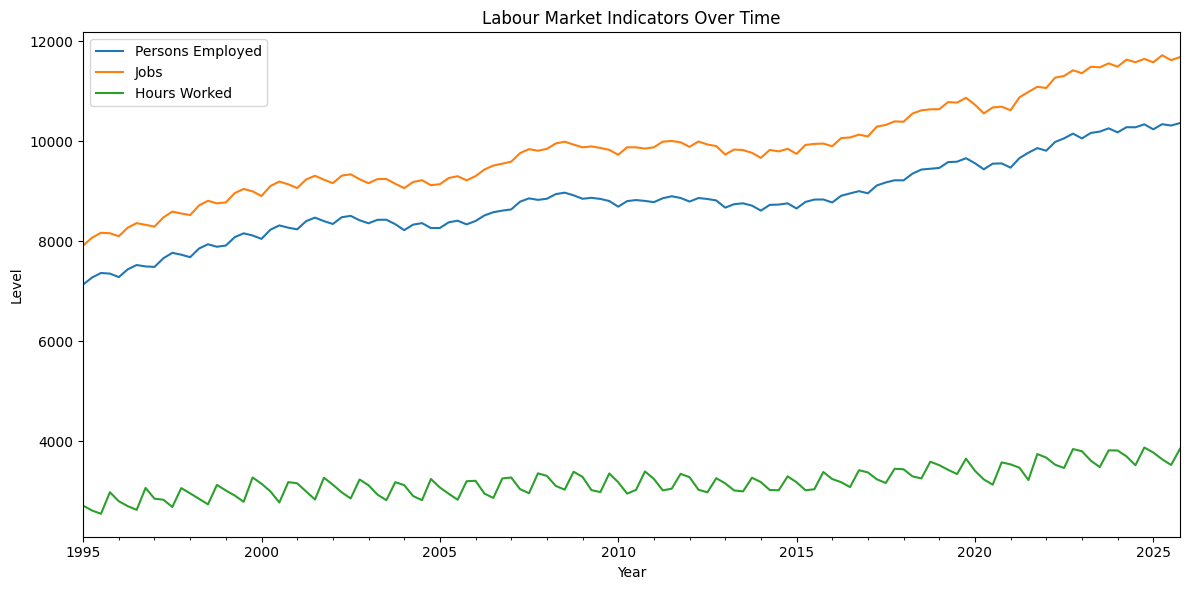

In [23]:
# -----------------------------
# 5.5.1 Labour indicators trends
# -----------------------------

df_total = df_q[
    (df_q["sbi_code"] == "T001081") &
    (df_q["TypeWerkenden_Title"] == "Totaal")
]

labour_trends = (
    df_total
    .set_index("period_enddate")[
        ["WerkzamePersonen", "Banen", "GewerkteUren"]
    ]
)

labour_trends.plot(figsize=(12,6))

plt.title("Labour Market Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Level")

plt.legend([
    "Persons Employed",
    "Jobs",
    "Hours Worked"
])

plt.tight_layout()
plt.show()

C:\Users\Yanni\AppData\Local\Temp\ipykernel_19096\2319161120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total["jobs_per_worker"] = (


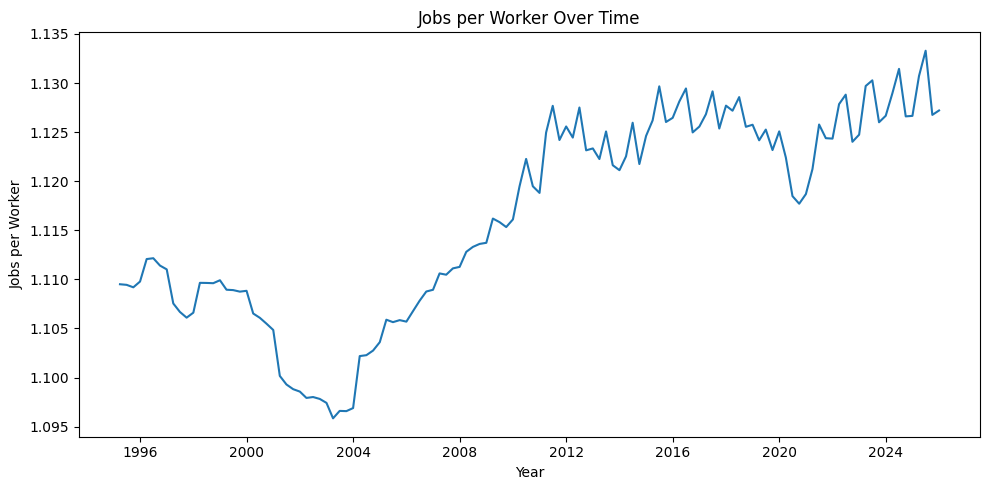

In [24]:
# -----------------------------
# 5.5.2 Jobs per worker
# -----------------------------

df_total["jobs_per_worker"] = (
    df_total["Banen"] / df_total["WerkzamePersonen"]
)

plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["jobs_per_worker"]
)

plt.title("Jobs per Worker Over Time")
plt.xlabel("Year")
plt.ylabel("Jobs per Worker")

plt.tight_layout()
plt.show()

C:\Users\Yanni\AppData\Local\Temp\ipykernel_19096\2207470469.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total["hours_per_worker"] = (


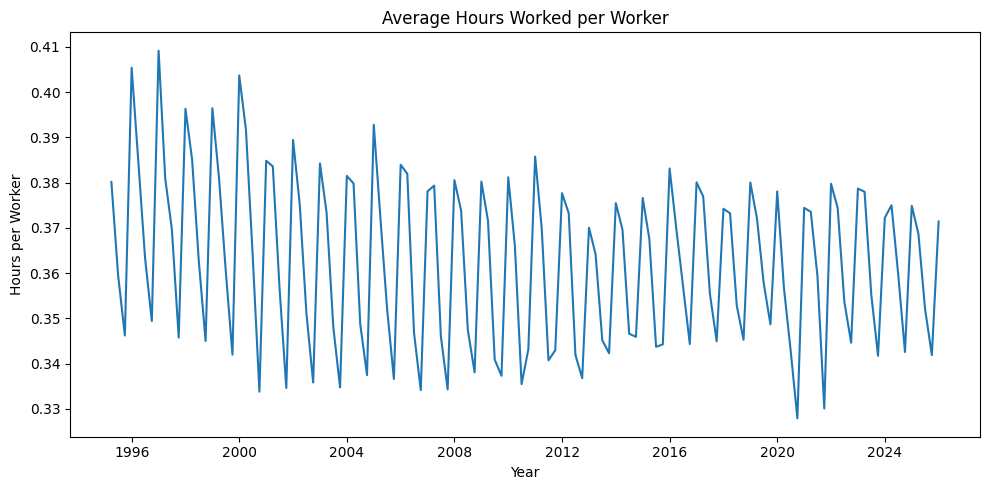

In [25]:
# -----------------------------
# 5.5.3 Hours per worker
# -----------------------------

df_total["hours_per_worker"] = (
    df_total["GewerkteUren"] / df_total["WerkzamePersonen"]
)

plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["hours_per_worker"]
)

plt.title("Average Hours Worked per Worker")
plt.xlabel("Year")
plt.ylabel("Hours per Worker")

plt.tight_layout()
plt.show()

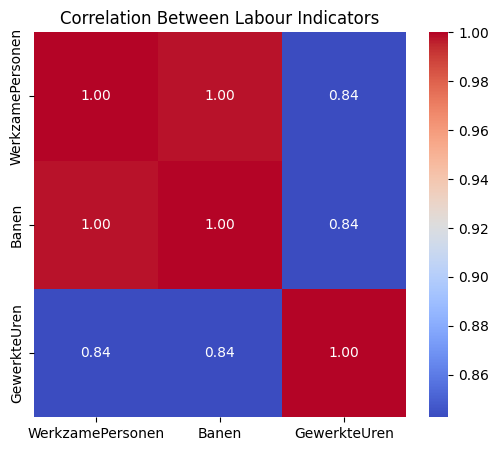

In [26]:
# -----------------------------
# 5.5.4 Correlation analysis
# -----------------------------

corr = df_total[
    ["WerkzamePersonen", "Banen", "GewerkteUren"]
].corr()

corr

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Labour Indicators")

plt.show()

#### Interpretation - Labour Market Indictors Analysis

1. Overall labour market growth

The first graph shows that all three labour indicators increased steadily between 1995 and 2025.

Key observations:

WerkzamePersonen increased from ~7,200 to ~10,400.

Banen increased from ~8,100 to ~11,700.

GewerkteUren increased from ~2,700 to ~3,800.

Interpretation:

The Dutch labour market experienced long-term expansion.

Employment growth accelerated after 2014, following the recovery from the global financial crisis.

A visible dip around 2020 reflects the COVID-19 shock, after which employment quickly recovered.

Implication for sick leave modelling:

Labour market expansions can increase work pressure and staffing constraints, which may influence absenteeism rates.

2. Jobs per worker

The jobs-per-worker ratio increased from roughly:

~1.10 (1995)
→ ~1.13 (2025)

Interpretation:

On average, workers hold slightly more jobs per person over time.

This suggests an increase in:

part-time work

multiple-job holding

labour market flexibility

The temporary drop around 2001–2004 may reflect economic slowdown.

Implication:

Workers with multiple jobs may experience higher workload or scheduling stress, which could influence absenteeism behavior.

3. Hours worked per worker

The graph shows:

A slight long-term decline in hours worked per worker.

Strong quarterly seasonality.

Interpretation:

Even though employment increased, average hours per worker did not grow proportionally.

This indicates:

increasing part-time employment

structural changes in working patterns.

Implication:

More part-time work may influence sick leave statistics, since absence durations and patterns differ for part-time workers.

4. Correlation between labour indicators

Correlation results:

Variables	Correlation
WerkzamePersonen – Banen	~1.00
WerkzamePersonen – GewerkteUren	~0.84
Banen – GewerkteUren	~0.84

Interpretation:

WerkzamePersonen and Banen are almost perfectly correlated.

This is expected because:

more workers → more jobs

structural labour market growth drives both indicators.

However:

Hours worked is slightly less correlated (0.84).

This indicates:

employment growth does not fully translate into proportional hours worked.

structural changes like part-time employment influence total hours.

Implication for modelling:

WerkzamePersonen and Banen are highly redundant variables.

For predictive modelling, one of them may be sufficient.

Key insights from Section 5.5

1️⃣ The Dutch labour market experienced strong long-term growth.

2️⃣ The number of jobs grew slightly faster than the number of workers, indicating increasing labour market flexibility.

3️⃣ Average hours per worker slightly declined, suggesting structural growth of part-time employment.

4️⃣ Labour indicators are highly correlated, meaning they capture similar economic dynamics.

How this connects to sick leave prediction

These variables capture labour market pressure:

Possible hypotheses:

Strong labour markets → higher workload → higher sick leave risk

More part-time work → different absenteeism patterns

Multiple jobs → higher fatigue risk

These relationships could be explored later in feature engineering.

### Seasonality analysis

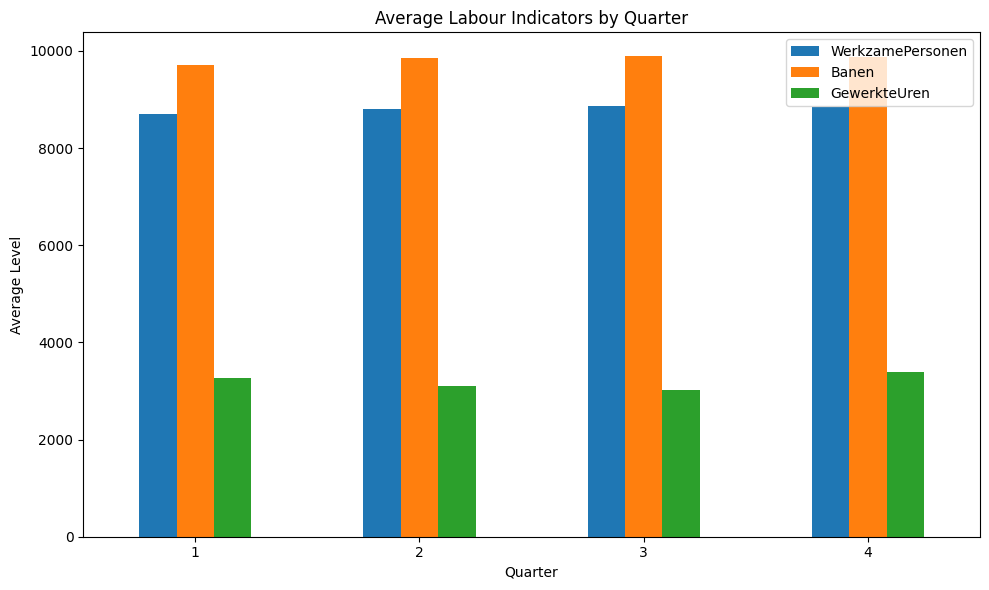

In [27]:
# -----------------------------
# 5.6.1 Seasonality by quarter
# -----------------------------


df_total = df_q[
    (df_q["sbi_code"] == "T001081") &
    (df_q["TypeWerkenden_Title"] == "Totaal")
]

seasonal_avg = (
    df_total
    .groupby("quarter")[["WerkzamePersonen", "Banen", "GewerkteUren"]]
    .mean()
)

seasonal_avg.plot(kind="bar", figsize=(10,6))

plt.title("Average Labour Indicators by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Level")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

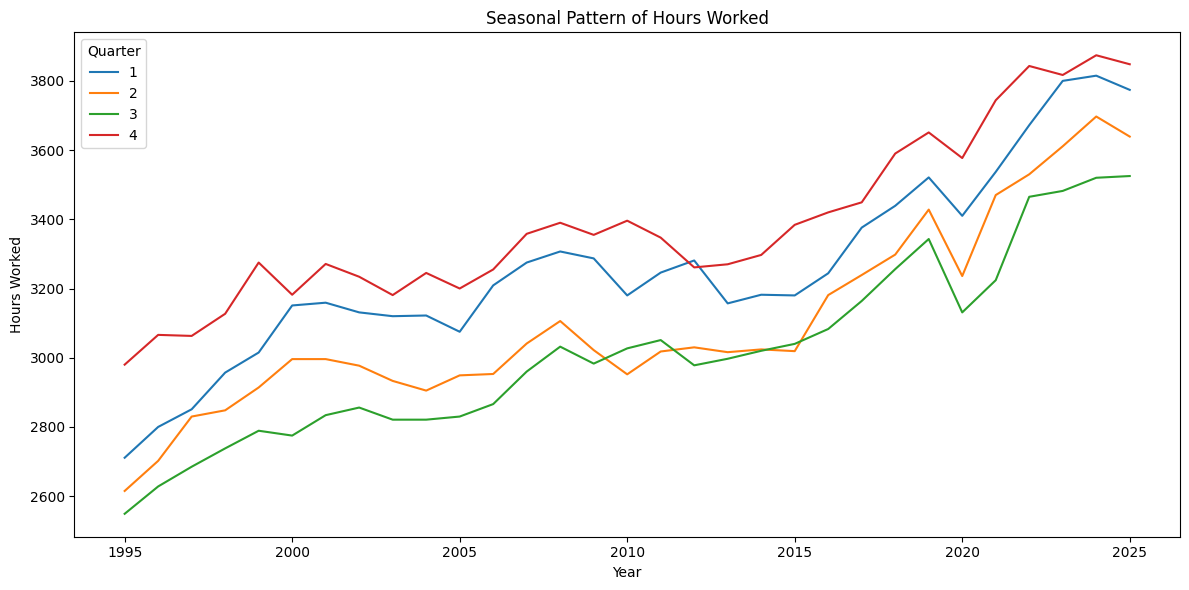

In [28]:
# -----------------------------
# 5.6.2 Hours worked seasonality
# -----------------------------

hours_seasonality = (
    df_total
    .pivot_table(
        index="year",
        columns="quarter",
        values="GewerkteUren"
    )
)

hours_seasonality.plot(figsize=(12,6))

plt.title("Seasonal Pattern of Hours Worked")
plt.xlabel("Year")
plt.ylabel("Hours Worked")

plt.legend(title="Quarter")

plt.tight_layout()
plt.show()

In [29]:
# -----------------------------
# 5.6.3 Seasonal index
# -----------------------------

quarter_avg = df_total.groupby("quarter")["GewerkteUren"].mean()

seasonal_index = quarter_avg / quarter_avg.mean()

seasonal_index

quarter
1    1.021118
2    0.972491
3    0.945169
4    1.061221
Name: GewerkteUren, dtype: float64

#### Interpretation — Seasonality Analysis

1. Quarterly patterns in labour indicators

The first figure shows the average level of labour indicators by quarter.

Key observations:

WerkzamePersonen and Banen are relatively stable across quarters.

GewerkteUren shows clearer seasonal variation.

Interpretation:

Employment levels change slowly over time, so they do not fluctuate strongly within a year.

Working hours adjust more easily and therefore show stronger seasonal behavior.

This reflects how firms typically react to short-term demand fluctuations:

adjust working hours first

adjust employment levels later.

2. Seasonal pattern of hours worked

The second graph shows the seasonal pattern of hours worked for each year.

Two patterns are visible:

Long-term trend

Hours worked increased steadily between 1995 and 2025, reflecting overall labour market expansion.

Within-year seasonality

There is a consistent ranking across quarters:

Q4  → highest activity
Q1  → second highest
Q2  → moderate
Q3  → lowest

This pattern repeats throughout the time series.

3. Seasonal index interpretation

Your calculated seasonal index is:

Quarter	Seasonal Index
Q1	1.021
Q2	0.972
Q3	0.945
Q4	1.061

Interpretation:

Q4 has the highest labour activity, about 6% above average.

Q3 has the lowest labour activity, about 5.5% below average.

Q1 is slightly above average.

Q2 is slightly below average.

This suggests a clear seasonal cycle in working hours.

Possible explanations include:

summer holidays in Q3

increased production before year-end in Q4

recovery of activity in Q1 after holidays

4. Implications for labour market modelling

The presence of clear seasonal patterns implies that time-based features should be included in predictive models.

Relevant features could include:

quarter indicators

year trends

lagged labour indicators

Seasonality is particularly important because it reflects systematic changes in labour demand and working hours throughout the year.

Key insight from Section 5.6

The Dutch labour market exhibits stable employment levels but clear seasonal variation in working hours, with lower activity during Q3 and higher activity during Q4.

These seasonal dynamics should be considered when analysing labour market outcomes such as absenteeism or sick leave patterns.

# Summary and Key Insights

Dataset overview

This notebook explored the CBS labour market dataset (85920NED) covering the period 1995–2025.
The dataset contains quarterly labour indicators for multiple sectors and worker types in the Netherlands.

The main indicators analysed were:

- WerkzamePersonen – number of employed persons
- Banen – number of jobs
- GewerkteUren – hours worked

These indicators were analysed across:

- time
- economic sectors (SBI)
- worker types (Werknemers vs Zelfstandigen)

Key Insights
1. Strong long-term labour market growth

All labour indicators show a clear upward trend between 1995 and 2025, indicating sustained labour market expansion.
Employment growth accelerated after 2014 and recovered quickly after the COVID-19 shock in 2020.

Implication for modelling:
Labour market expansion may increase work pressure and labour demand, which can influence absenteeism patterns.

2. Structural differences across sectors

Employment is concentrated in a few large sectors:

- G-I Handel, vervoer en horeca
- M-N Zakelijke dienstverlening
- Q Gezondheids- en welzijnszorg

Some sectors also experienced strong employment growth, particularly:

- J Informatie en communicatie
- Q Gezondheids- en welzijnszorg
- M-N Zakelijke dienstverlening

Implication:
Sector-level labour indicators may help explain sectoral differences in sick leave patterns.

3. Increasing labour market flexibility

The ratio of jobs per worker increased slightly over time.

This suggests:

- more part-time employment
- more multiple job holding

Implication:
Workers holding multiple jobs or working flexible schedules may exhibit different absenteeism behaviour.

4. Growth of self-employment in some sectors

The share of Zelfstandigen increased in several sectors, particularly:

- F Bouwnijverheid
- R-U Cultuur, recreatie, overige diensten

In contrast, sectors such as O Openbaar bestuur en overheidsdiensten remain almost entirely employee-based.

Implication:
Worker type composition may influence absenteeism risk and reporting behaviour.

5. Clear seasonal labour patterns

Seasonality analysis shows:

- Q4 has the highest labour activity
- Q3 has the lowest activity, likely due to summer holidays

Seasonal index (hours worked):

Quarter	Seasonal Index
Q1	~1.02
Q2	~0.97
Q3	~0.95
Q4	~1.06

Implication:
Seasonality features (e.g., quarter indicators) should be included in predictive models.

Potential Features for Sick Leave Prediction

The explored labour indicators could be used to construct modelling features such as:

Macro labour indicators

- total employment

- jobs per worker

- hours per worker

Sector features

- employment level by sector

- sector growth rates

- sector employment shares

Worker composition

- share of zelfstandigen vs werknemers

- sectoral worker type composition

Temporal features

- year trend

- quarter (seasonality)

Conclusion

The labour market dataset provides valuable macro-economic and structural indicators that can serve as explanatory variables in sick leave prediction models. In particular, sector dynamics, worker composition, labour intensity, and seasonal patterns may help capture underlying labour market conditions that influence absenteeism behaviour.